# AI ANALYST LAB

![](../_img/ai_analyst_lab.png)

### A Hands-on Course on AI for Data Analysts
## Review 04: Mathematical Statistics

Feedback should be sent to [goran.milovanovic@datakolektiv.com](mailto:goran.milovanovic@datakolektiv.com).

This is a **review notebook**. Across eight sessions you quietly used a whole toolbox of *mathematical statistics* — estimators, sums of squares, standard errors, likelihood, mean squares, the F-test — often without stopping to unpack the machinery. This review is that pause. It assembles the **mathematical spine** of the course into one gentle, from-first-principles story, and at every step it names the Session where you first met the idea.

***
### What we will do today

We build the core of **estimation theory** one small idea at a time, and we compute everything ourselves.

| Section | Idea | You met it in |
|---|---|---|
| RM.1 | What an **estimator** is | Sessions 01, 02, 04 |
| RM.2 | **Bias** of an estimator (and the `n−1` puzzle) | Sessions 01, 04 |
| RM.3 | **Degrees of freedom** — what they are, how they work | Sessions 01, 03, 04 |
| RM.4 | **Variance of an estimator** & the standard error | Sessions 01, 03, 04, 05 |
| RM.5 | **MSE = Bias² + Variance** | *(new here)* |
| RM.6 | **Sum of squares**, everywhere | Sessions 04, 06, 08 |
| RM.7 | **Least squares** & R² | Sessions 04, 05, 08 |
| RM.8 | **Covariance → correlation** | Session 04 |
| RM.9 | **Likelihood** & Maximum Likelihood | Sessions 05, 02 |
| RM.10 | **Mean Squares** (SS ÷ df) | Session 04 |
| RM.11 | The **F-test** for regression | Session 04 |

Method, as always: **compute first, then read the number.** This review assumes the probability of **Review 02** and, in one spot, the entropy of **Review 03** — but everything else is built from scratch.

***
The tools we need — NumPy for the math, pandas for the one real dataset, matplotlib for pictures, and a couple of statistics libraries to *check our hand computations*.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats            # for the F-distribution p-value
import statsmodels.api as sm       # to cross-check our by-hand F-test

plt.rcParams["figure.figsize"] = (8, 5)
rng = np.random.default_rng(seed=2026)   # one seeded generator for all simulations
print("Ready.")

Ready.


***
## RM.1 What is an estimator?

Every number you have reported in this course was a **guess about a larger world you could not fully see.** When Session 01 computed the average hourly bike demand, the *real* long-run average — call it $\mu$ — was unknown; you had only a sample. Mathematical statistics is the study of how to make such guesses well, and how much to trust them. Three words make the whole subject precise:

- A **parameter** is a fixed, usually *unknown*, number describing the whole population: the true mean $\mu$, the true standard deviation $\sigma$, a true churn probability $p$ (Session 05), a true regression slope $\beta$ (Session 04).
- An **estimator** is a *recipe* — a formula you apply to a sample — that guesses a parameter. The sample mean $\bar{x} = \frac{1}{n}\sum x_i$ is an estimator of $\mu$.
- A **point estimate** is the single number the recipe spits out on *your* particular sample.

The universal notation, which you saw as early as Session 01, is the **hat**: $\hat{\mu}$, $\hat{p}$, $\hat{\beta}$ all mean *"estimated from data."*

The one idea to internalise: **an estimator is itself random.** Feed it a different sample and it gives a different answer. Let's watch that happen — pretend the true world is $\mu = 100$, and draw three separate samples:

In [2]:
mu_true = 100          # the parameter — in real life we would NOT know this
for k in range(1, 4):
    sample = rng.normal(loc=mu_true, scale=15, size=30)   # a fresh sample of 30
    print(f"sample {k}:  x-bar = {sample.mean():.2f}   (guessing mu = {mu_true})")

sample 1:  x-bar = 99.95   (guessing mu = 100)
sample 2:  x-bar = 106.99   (guessing mu = 100)
sample 3:  x-bar = 97.58   (guessing mu = 100)


Three samples, three different estimates — none exactly 100, all in the neighbourhood. Because an estimator is random, the sensible questions are statistical: *on average, does it hit the truth?* (bias), and *how much does it bounce around?* (variance). Those are the next three sections.

***
## RM.2 Bias of an estimator — and the puzzle of `n − 1`

The **bias** of an estimator is how far off it is *on average*, across all possible samples:

$$\text{Bias}(\hat{\theta}) = \mathbb{E}[\hat{\theta}] - \theta$$

An estimator is **unbiased** if its bias is zero — if, over infinitely many samples, its guesses centre exactly on the truth. The sample mean is unbiased for $\mu$. But there is a famous, genuinely puzzling case you have used since Session 01 without a full explanation: **why does the sample variance divide by `n − 1` instead of `n`?**

$$s^2 = \frac{1}{n-1}\sum_{i=1}^{n}(x_i - \bar{x})^2 \qquad \text{(the "Bessel's correction" you met in Session 01)}$$

Let's *prove to ourselves by simulation* that dividing by `n` is biased — it systematically **under**-estimates the true variance — while `n − 1` fixes it. We draw 20,000 samples from a world with true variance $\sigma^2 = 25$, and average each estimator's answer:

In [3]:
sigma2_true = 25          # true variance (so true sigma = 5)
n = 5                     # small samples make the bias easy to see
div_n, div_n1 = [], []
for _ in range(20_000):
    s = rng.normal(0, np.sqrt(sigma2_true), size=n)
    dev2 = np.sum((s - s.mean())**2)      # sum of squared deviations from the sample mean
    div_n.append(dev2 / n)                # the "obvious" (but biased) estimator
    div_n1.append(dev2 / (n - 1))         # Bessel's correction

print(f"true variance            : {sigma2_true}")
print(f"average of  (.../ n )     : {np.mean(div_n):.2f}   <- too low: BIASED")
print(f"average of  (.../ n-1)    : {np.mean(div_n1):.2f}   <- on target: UNBIASED")

true variance            : 25
average of  (.../ n )     : 19.93   <- too low: BIASED
average of  (.../ n-1)    : 24.91   <- on target: UNBIASED


The `÷ n` version lands around **20**, not 25 — a real, repeatable bias. The `÷ (n−1)` version centres on 25. Something about computing the mean *first* costs us. That "something" has a name — and it is the subject of the next section, one of the most important (and most often glossed-over) ideas in all of statistics.

***
## RM.3 Degrees of freedom — what they are, and how they work

**Degrees of freedom (df)** is one of the most-used and least-explained ideas in statistics. Here is the whole thing in one sentence:

> **Degrees of freedom = the number of values in a calculation that are still free to vary, once you have pinned down a summary of them.**

### The "aha" example

Suppose I tell you three numbers have a **mean of 10**. How many of them can you choose freely?

- Pick the first: say **4**. (free)
- Pick the second: say **15**. (free)
- The third? You have **no choice** — to make the average 10, the three must sum to 30, so the third is forced to be $30 - 4 - 15 = 11$.

Three numbers, one constraint (their mean) → only **2** are free to vary. We say they have **2 degrees of freedom**. Let's see the constraint bite:

In [4]:
# Once the mean is fixed, the deviations from the mean are NOT all independent —
# they are forced to sum to exactly zero.
sample = rng.normal(50, 10, size=6)
deviations = sample - sample.mean()
print("the 6 deviations from the mean:", np.round(deviations, 2))
print("their sum:", round(deviations.sum(), 10), " <- always zero, by construction")
print("=> only 5 of the 6 deviations are free; the 6th is determined. df = n - 1 = 5")

the 6 deviations from the mean: [-18.34  -7.52  18.38   5.23   8.    -5.75]
their sum: 0.0  <- always zero, by construction
=> only 5 of the 6 deviations are free; the 6th is determined. df = n - 1 = 5


### The deep answer to the `n − 1` puzzle

Now RM.2 makes sense. To compute a variance we must first compute the sample mean $\bar{x}$. That **uses up one degree of freedom**: the deviations $(x_i - \bar{x})$ are forced to sum to zero, so only $n - 1$ of them are genuinely independent. We are averaging squared deviations, but there are only $n-1$ *free* ones — so we divide by $n-1$, not $n$. Bessel's correction is not a fudge; it is **honest accounting of degrees of freedom.**

### The general rule (a budget you spend)

Think of it as a budget:

> You start with **$n$ independent facts** (your $n$ data points). **Every quantity you estimate from the data spends one degree of freedom.** What remains is your df.

$$\boxed{\;\text{df} \;=\; (\text{number of observations}) \;-\; (\text{number of parameters estimated from the data})\;}$$

- Sample **variance**: estimate 1 thing (the mean) → $\text{df} = n - 1$. *(Session 01)*
- Simple **regression** $y = \beta_0 + \beta_1 x$: estimate 2 things (intercept and slope) → residual $\text{df} = n - 2$. *(Session 04)*
- Multiple regression with $p$ predictors plus intercept: $\text{df} = n - (p+1)$.
- A $r \times c$ **contingency table** (the chi-square test of Session 03): $\text{df} = (r-1)(c-1)$.

### Why you will keep meeting it

Degrees of freedom is not trivia — it is the number that:

1. **corrects estimators for bias** (this section), and
2. **turns a Sum of Squares into a Mean Square** (RM.10) — you *divide a sum of squares by its degrees of freedom*, and
3. indexes the **t, chi-square, and F distributions** (Sessions 03–04) that inference relies on.

Keep the budget picture in mind and every `n−1`, `n−2`, and `n−p` in the rest of this review will feel inevitable rather than arbitrary.

***
## RM.4 Variance of an estimator, and the standard error

Since an estimator is random (RM.1), it has its own **variance** — a measure of how much its guesses bounce around from sample to sample. The **standard error (SE)** is simply the *standard deviation of that bounce*:

$$\text{SE}(\hat{\theta}) = \sqrt{\operatorname{Var}(\hat{\theta})}\,.$$

You already met the most important case in **Review 02** and **Session 01**: for the sample mean, $\text{SE}(\bar{x}) = \sigma/\sqrt{n}$, estimated in practice by $s/\sqrt{n}$. The key reframing here: **the standard error is the standard deviation of the estimator's _sampling distribution_** — not of the raw data. That single idea unifies every "SE" in the course:

- SE of the mean, $s/\sqrt{n}$ *(Session 01)*
- SE of a difference of proportions *(Session 03)*
- SE of a regression coefficient $\hat{\beta}$ *(Session 04)*
- SE of a logistic-regression coefficient *(Session 05)*
- and, when no tidy formula exists, the **bootstrap** standard error you obtained by resampling *(Session 02)*

Let's confirm the $\sigma/\sqrt{n}$ law by *building* the sampling distribution — drawing 10,000 sample means and measuring their spread directly:

SE measured from 10,000 sample means : 2.3490
SE predicted by  sigma / sqrt(n)      : 2.3717


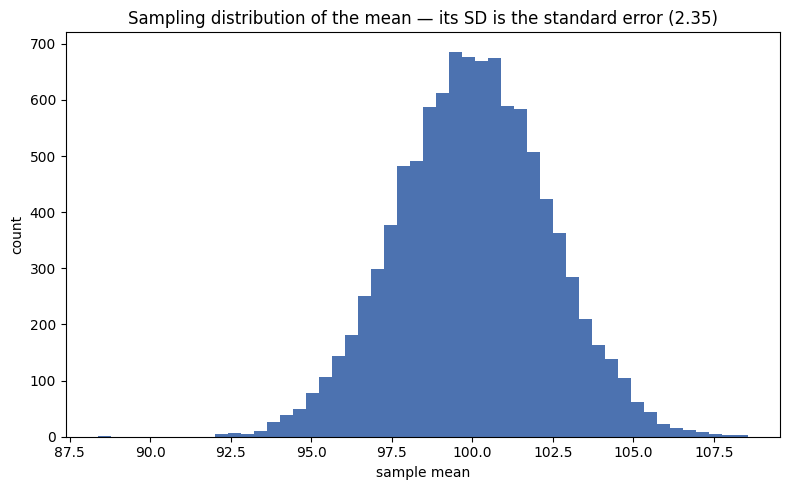

In [5]:
sigma, n = 15, 40
means = np.array([rng.normal(100, sigma, size=n).mean() for _ in range(10_000)])

print(f"SE measured from 10,000 sample means : {means.std(ddof=1):.4f}")
print(f"SE predicted by  sigma / sqrt(n)      : {sigma/np.sqrt(n):.4f}")

plt.hist(means, bins=50, color="#4c72b0")
plt.title(f"Sampling distribution of the mean — its SD is the standard error ({means.std(ddof=1):.2f})")
plt.xlabel("sample mean"); plt.ylabel("count"); plt.tight_layout(); plt.show()

Measured spread and the formula agree. The standard error is *the estimator's own standard deviation* — the raw material of every confidence interval and every "estimate ÷ SE" test statistic in the course.

***
## RM.5 Putting it together: MSE = Bias² + Variance

We now have the two ways an estimator can be wrong: it can be **off-centre** (bias) and it can be **jittery** (variance). The single number that combines them is the **Mean Squared Error** — the average squared distance between the estimator and the truth:

$$\text{MSE}(\hat{\theta}) = \mathbb{E}\big[(\hat{\theta} - \theta)^2\big] \;=\; \underbrace{\text{Bias}(\hat{\theta})^2}_{\text{how off-centre}} \;+\; \underbrace{\operatorname{Var}(\hat{\theta})}_{\text{how jittery}}$$

This beautiful identity (new to the course, but worth knowing) says a good estimator needs *both* low bias *and* low variance. Let's verify it numerically on the biased `÷ n` variance estimator from RM.2:

In [6]:
sigma2_true, n = 25, 5
est = np.array([np.sum((s - s.mean())**2) / n
                for s in (rng.normal(0, np.sqrt(sigma2_true), size=n) for _ in range(50_000))])

bias = est.mean() - sigma2_true
var  = est.var()
mse  = np.mean((est - sigma2_true)**2)

print(f"Bias        : {bias:.3f}")
print(f"Bias^2      : {bias**2:.3f}")
print(f"Variance    : {var:.3f}")
print(f"Bias^2 + Var : {bias**2 + var:.3f}")
print(f"MSE (direct) : {mse:.3f}   <- matches Bias^2 + Variance")

Bias        : -5.048
Bias^2      : 25.479
Variance    : 200.583
Bias^2 + Var : 226.061
MSE (direct) : 226.061   <- matches Bias^2 + Variance


The identity holds to the last decimal. This is the lens through which statisticians judge any estimator — and, foreshadowing beyond this course, it is exactly the tension ("more flexibility lowers bias but raises variance") that sits underneath *overfitting* in Session 08.

***
## RM.6 Sum of squares, everywhere

If one quantity deserves the title *"most reused number in the course,"* it is the **sum of squares**: add up the squared distances of your data from some centre.

$$\text{SS} = \sum_{i=1}^{n} (x_i - c)^2$$

You have computed this, under different names, in at least three sessions:

- **Session 04** — the **residual sum of squares** of a regression, $\sum (y_i - \hat{y}_i)^2$.
- **Session 06** — the **within-cluster sum of squares** (WCSS / inertia) that k-means minimises.
- **Session 08** — the **squared-error impurity** a regression tree reduces at each split.

They are all the same idea: *squared Euclidean distance from a centre.* And there is a lovely fact that explains why the **mean** shows up as the "centre" so often: **the mean is the single point that minimises the sum of squared distances.** Let's see it — sweep a candidate centre across a small dataset and watch SS bottom out exactly at the mean:

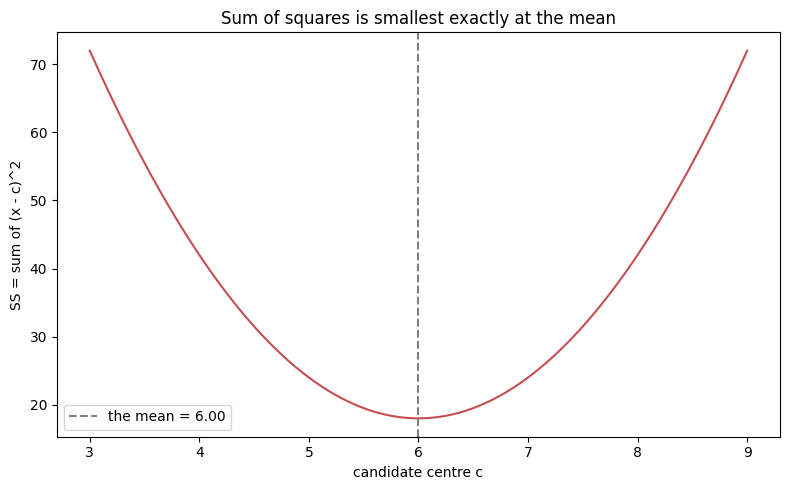

SS at the mean (6.00) : 18.000  <- the minimum
SS at 6.5              : 19.500  <- larger


In [7]:
data = np.array([4.0, 4.0, 5.0, 7.0, 8.0, 8.0])
def SS(center):
    return np.sum((data - center)**2)

centers = np.linspace(3, 9, 200)
plt.plot(centers, [SS(c) for c in centers], color="#c44e52")
plt.axvline(data.mean(), ls="--", color="grey", label=f"the mean = {data.mean():.2f}")
plt.title("Sum of squares is smallest exactly at the mean")
plt.xlabel("candidate centre c"); plt.ylabel("SS = sum of (x - c)^2")
plt.legend(); plt.tight_layout(); plt.show()

print(f"SS at the mean ({data.mean():.2f}) : {SS(data.mean()):.3f}  <- the minimum")
print(f"SS at 6.5              : {SS(6.5):.3f}  <- larger")

This is why "predict the average" is the natural baseline everywhere: the mean is the least-squares summary of a set of numbers. Everything about regression follows from taking this idea and letting the "centre" depend on other variables.

***
## RM.7 Least squares and R²

**Session 04** fit a line to data. The recipe has a name: **Ordinary Least Squares (OLS)** — choose the intercept and slope that make the **residual sum of squares as small as possible**:

$$\text{SS}_{\text{res}} = \sum (y_i - \hat{y}_i)^2 \quad\longrightarrow\quad \text{minimise}$$

Then comes the score you have quoted since Session 04, **R²**, built from a three-way split of the total sum of squares:

$$\underbrace{\sum (y_i - \bar{y})^2}_{\text{SS}_{\text{tot}}\;=\;\text{total spread}} \;=\; \underbrace{\sum (\hat{y}_i - \bar{y})^2}_{\text{SS}_{\text{reg}}\;=\;\text{explained}} \;+\; \underbrace{\sum (y_i - \hat{y}_i)^2}_{\text{SS}_{\text{res}}\;=\;\text{left over}}, \qquad R^2 = 1 - \frac{\text{SS}_{\text{res}}}{\text{SS}_{\text{tot}}}$$

$R^2$ is literally *"the fraction of the data's spread that the model explains."* Let's compute it **by hand** on the **Wine Quality** data (Session 04) — predicting a wine's quality from its alcohol content — and check it against scikit-learn:

In [8]:
wine = pd.read_csv("../_data/wine_quality/winequality-red.csv", sep=";")
x = wine["alcohol"].to_numpy()
y = wine["quality"].to_numpy()
n = len(y)

# Ordinary least squares for a single predictor (the closed-form slope & intercept).
b1 = np.cov(x, y, ddof=1)[0, 1] / np.var(x, ddof=1)
b0 = y.mean() - b1 * x.mean()
y_hat = b0 + b1 * x

SS_tot = np.sum((y - y.mean())**2)
SS_res = np.sum((y - y_hat)**2)
SS_reg = SS_tot - SS_res
R2 = 1 - SS_res / SS_tot

print(f"slope b1 = {b1:.4f},  intercept b0 = {b0:.4f}")
print(f"SS_tot = {SS_tot:.1f}  =  SS_reg ({SS_reg:.1f})  +  SS_res ({SS_res:.1f})")
print(f"R^2 (by hand)                 : {R2:.4f}")
print(f"R^2 (= r^2 for one predictor) : {np.corrcoef(x, y)[0,1]**2:.4f}")

slope b1 = 0.3608,  intercept b0 = 1.8750
SS_tot = 1042.2  =  SS_reg (236.3)  +  SS_res (805.9)
R^2 (by hand)                 : 0.2267
R^2 (= r^2 for one predictor) : 0.2267


About **23%** of the variation in wine quality is explained by alcohol alone. Note the tidy fact, true only for *simple* regression: $R^2 = r^2$, the square of the Pearson correlation — which is exactly the quantity we build next. We will reuse this same `SS_reg`, `SS_res`, and their degrees of freedom in RM.10–RM.11.

***
## RM.8 Covariance → correlation

Where does that slope come from? From **covariance** — the quantity that measures whether two variables move together. Take each variable's deviations from its own mean, multiply them pointwise, and average (with the `n−1` you now understand):

$$\operatorname{cov}(x, y) = \frac{1}{n-1}\sum (x_i - \bar{x})(y_i - \bar{y})$$

Positive when the two rise together, negative when one rises as the other falls. Its one flaw: its **units are unwieldy** (here, "alcohol-percent × quality-points"), so its size is hard to read. The fix is to **standardise** it — divide by each variable's standard deviation — giving the **Pearson correlation coefficient** from Session 04, a clean unitless number in $[-1, 1]$:

$$r = \frac{\operatorname{cov}(x, y)}{s_x \, s_y}$$

In [9]:
cov_xy = np.cov(x, y, ddof=1)[0, 1]
r = cov_xy / (x.std(ddof=1) * y.std(ddof=1))

print(f"covariance(alcohol, quality) : {cov_xy:.4f}   (units: %alc x quality-points)")
print(f"correlation r                : {r:.4f}   (unitless, in [-1, 1])")
print(f"cross-check np.corrcoef       : {np.corrcoef(x, y)[0,1]:.4f}")
print(f"and note  b1 = cov / var(x)   : {cov_xy / np.var(x, ddof=1):.4f}  = the RM.7 slope")

covariance(alcohol, quality) : 0.4098   (units: %alc x quality-points)
correlation r                : 0.4762   (unitless, in [-1, 1])
cross-check np.corrcoef       : 0.4762
and note  b1 = cov / var(x)   : 0.3608  = the RM.7 slope


So correlation is just **standardised covariance**, and the regression slope is **covariance divided by the predictor's variance**. The three ideas — covariance, correlation, slope — are one family, separated only by what you divide by.

***
## RM.9 Likelihood and Maximum Likelihood

Least squares is one way to fit a model. **Session 05** used a different, equally fundamental one to fit its churn model: **maximum likelihood**. It rests on a distinction that trips up almost everyone at first — the difference between **probability** and **likelihood** (first flagged, in passing, back in Session 02):

- **Probability** runs *forwards*: the parameter is fixed, and we ask how probable some data is. *"If a coin is fair ($p = 0.5$), how probable is HHT?"*
- **Likelihood** runs *backwards*: the **data is fixed** (we already observed it), and we ask how well different parameter values *explain* it. *"Given that we saw HHT, which value of $p$ makes that outcome most probable?"*

The **likelihood function** $L(\theta)$ is the probability of the observed data, read as a function of the unknown parameter. **Maximum Likelihood Estimation (MLE)** picks the parameter that makes the data most probable — the peak of that curve. Let's do the canonical example: we flip a coin 20 times, see 14 heads, and let the data tell us $p$:

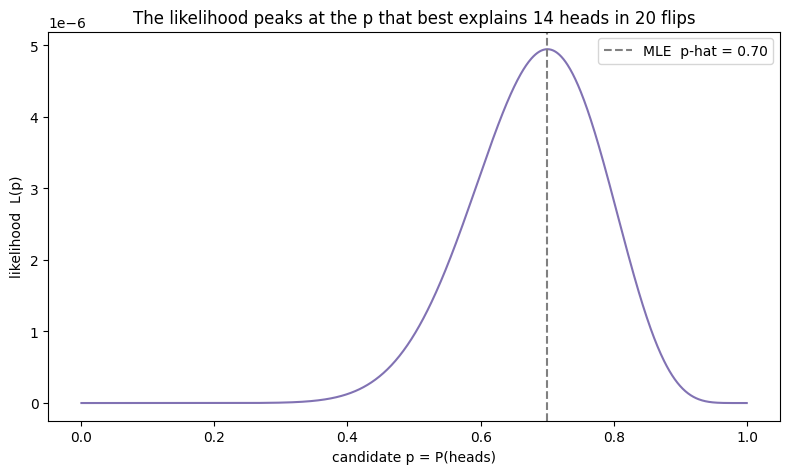

maximum-likelihood estimate p-hat : 0.700
the obvious answer  heads / flips  : 0.700   <- they agree


In [10]:
n_flips, n_heads = 20, 14

# Likelihood of the data for each candidate p: L(p) = p^heads * (1-p)^tails.
p_grid = np.linspace(0.001, 0.999, 999)
likelihood = p_grid**n_heads * (1 - p_grid)**(n_flips - n_heads)

p_mle = p_grid[np.argmax(likelihood)]
plt.plot(p_grid, likelihood, color="#8172b3")
plt.axvline(p_mle, ls="--", color="grey", label=f"MLE  p-hat = {p_mle:.2f}")
plt.title("The likelihood peaks at the p that best explains 14 heads in 20 flips")
plt.xlabel("candidate p = P(heads)"); plt.ylabel("likelihood  L(p)")
plt.legend(); plt.tight_layout(); plt.show()

print(f"maximum-likelihood estimate p-hat : {p_mle:.3f}")
print(f"the obvious answer  heads / flips  : {n_heads/n_flips:.3f}   <- they agree")

The likelihood peaks exactly at $\hat{p} = 14/20 = 0.7$ — MLE recovers the common-sense answer, but as the winner of a *principled* competition among all values of $p$.

**Two practical notes that Session 05 relied on.** (1) Likelihoods are products of many small probabilities, which underflow to zero on a computer; so we always maximise the **log-likelihood** $\ln L = \sum[\,y_i \ln p_i + (1-y_i)\ln(1-p_i)\,]$ instead — turning the product into a sum. (2) Logistic regression has no neat closed form like OLS, so it finds the maximum-likelihood coefficients by **iterative numerical optimisation** — which is exactly what happened, invisibly, when you called `.fit()` on the churn model.

***
## RM.10 From sums of squares to Mean Squares

We now braid two threads together: **sums of squares** (RM.6–RM.7) and **degrees of freedom** (RM.3). A **Mean Square** is nothing more than a sum of squares *divided by its degrees of freedom*:

$$\text{Mean Square} = \frac{\text{Sum of Squares}}{\text{degrees of freedom}}$$

Here is the quiet revelation: **the sample variance is already a mean square** — it is $\text{SS} \div (n-1)$. A "mean square" is just the average squared amount per free piece of information. Regression splits its total sum of squares into two, each with its own df, and dividing gives two mean squares. For our simple Wine regression (one predictor):

- **Regression:** $\text{SS}_{\text{reg}}$, with $\text{df}_{\text{reg}} = 1$ (one slope estimated) → $\text{MSR} = \text{SS}_{\text{reg}} / 1$
- **Residual (error):** $\text{SS}_{\text{res}}$, with $\text{df}_{\text{res}} = n - 2$ (intercept + slope spent) → $\text{MSE} = \text{SS}_{\text{res}} / (n-2)$

Let's lay it out as the classic **ANOVA table**:

In [11]:
df_reg = 1               # one predictor -> one degree of freedom for the model
df_res = n - 2           # n observations minus (intercept + slope)
df_tot = n - 1

MSR = SS_reg / df_reg    # regression mean square
MSE = SS_res / df_res    # error (residual) mean square

anova = pd.DataFrame({
    "Sum of Squares": [SS_reg, SS_res, SS_tot],
    "df":             [df_reg, df_res, df_tot],
    "Mean Square":    [MSR,    MSE,    np.nan],
}, index=["Regression", "Residual (error)", "Total"])
print(anova.round(3))
print(f"\nnote: MSE = SS_res / (n-2) = {MSE:.4f}  is an estimate of the residual variance;")
print(f"      and the plain sample variance of y is SS_tot/(n-1) = {SS_tot/df_tot:.4f}  (also a mean square).")

                  Sum of Squares    df  Mean Square
Regression               236.295     1      236.295
Residual (error)         805.870  1597        0.505
Total                   1042.165  1598          NaN

note: MSE = SS_res / (n-2) = 0.5046  is an estimate of the residual variance;
      and the plain sample variance of y is SS_tot/(n-1) = 0.6522  (also a mean square).


Every entry in that table is a sum of squares, a degrees-of-freedom count, or their ratio. Nothing new — just RM.3 and RM.6 standing next to each other. The final step turns these two mean squares into a test.

***
## RM.11 The F-test for regression

We have a mean square for what the model **explains** (MSR) and a mean square for what it **leaves unexplained** (MSE). Their ratio is the **F-statistic**:

$$F = \frac{\text{MSR}}{\text{MSE}} = \frac{\text{explained variance per df}}{\text{unexplained variance per df}}$$

The idea is beautifully simple: **is the variation the model explains bigger than the leftover noise — by more than we'd expect from chance?** If the predictor were useless, MSR and MSE would be similar and $F$ would sit near 1. A large $F$ says *"the model explains far more than noise"* — i.e., the regression as a whole is doing real work (it beats just predicting the mean). We read off a p-value from the **F-distribution**, indexed — of course — by the two degrees of freedom. Let's compute it by hand, then confirm against `statsmodels`:

In [12]:
F = MSR / MSE
p_value = 1 - stats.f.cdf(F, df_reg, df_res)     # tail area of the F-distribution
print(f"F = MSR / MSE = {MSR:.2f} / {MSE:.4f} = {F:.2f}")
print(f"p-value (F-distribution, df = {df_reg}, {df_res}) : {p_value:.2e}")

# Cross-check the entire computation against statsmodels' OLS.
model = sm.OLS(y, sm.add_constant(x)).fit()
print(f"\nstatsmodels F-statistic : {model.fvalue:.2f}   (matches our {F:.2f})")
print(f"statsmodels F p-value   : {model.f_pvalue:.2e}")

F = MSR / MSE = 236.29 / 0.5046 = 468.27
p-value (F-distribution, df = 1, 1597) : 0.00e+00

statsmodels F-statistic : 468.27   (matches our 468.27)
statsmodels F p-value   : 2.83e-91


Our by-hand $F \approx 468$ matches `statsmodels` exactly, with a p-value far below any threshold: alcohol is, overwhelmingly, a real predictor of wine quality — the model explains far more than chance. And notice how the whole review converged here: we took **sums of squares** (RM.6), divided them by their **degrees of freedom** (RM.3) to get **mean squares** (RM.10), and formed their ratio to test the model. Sessions 04's `F-statistic`, printed without explanation, is now something you can compute — and *read* — from first principles.

***
## RM.12 Recap — the mathematical spine, assembled

In one notebook we connected the machinery that ran quietly under all eight sessions:

- an **estimator** is a random recipe for guessing a parameter *(RM.1)*;
- we judge it by its **bias** *(RM.2)*, its **variance / standard error** *(RM.4)*, and their sum, **MSE = Bias² + Variance** *(RM.5)*;
- **degrees of freedom** — the count of free information after estimating — explains the `n−1`, and returns as the divisor that makes **mean squares** *(RM.3, RM.10)*;
- the **sum of squares** is the course's most reused quantity, powering **least squares**, **R²**, k-means, and trees *(RM.6–RM.7)*;
- **covariance and correlation** are its two-variable cousins *(RM.8)*;
- **maximum likelihood** is the second great way to fit a model — the engine inside logistic regression *(RM.9)*;
- and **mean squares** and the **F-test** turn sums of squares plus degrees of freedom into a verdict on the whole model *(RM.10–RM.11)*.

None of this replaces the sessions — it is the **connective tissue** beneath them. Every `hat`, every `n−1`, every `SS`, every `F` you have typed now has a home. That is what it means to move from *using* statistics to *understanding* it.

<hr>

![](../_img/DK_Logo_White_150.png)

DataKolektiv, 2026.

[hello@datakolektiv.com](mailto:hello@datakolektiv.com)

<font size=1>License: [GPLv3](../LICENSE). This Notebook is free software: you can redistribute it and/or modify it under the terms of the GNU General Public License as published by the Free Software Foundation, either version 3 of the License, or (at your option) any later version. This Notebook is distributed in the hope that it will be useful, but WITHOUT ANY WARRANTY; without even the implied warranty of MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE. See the GNU General Public License for more details.</font>